In [1]:
!pip install kagglehub torch torchvision matplotlib pandas scikit-learn

In [2]:
import os
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

In [3]:
print("Downloading dataset...")

path = kagglehub.dataset_download("emmarex/plantdisease")

print("Dataset downloaded at:")
print(path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset downloaded at:
/kaggle/input/plantdisease


In [4]:
print("\nDataset folders:")

for item in os.listdir(path):
    print(item)


Dataset folders:
PlantVillage
plantvillage


In [5]:
data_dir = None

for folder in os.listdir(path):
    full_path = os.path.join(path, folder)

    if os.path.isdir(full_path):
        data_dir = full_path
        break

print("Using data directory:", data_dir)

Using data directory: /kaggle/input/plantdisease/PlantVillage


In [6]:
classes = os.listdir(data_dir)

print("Number of classes:", len(classes))
print("\nExample classes:")
print(classes[:10])

Number of classes: 15

Example classes:
['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot']


In [7]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(data_dir, cls)
    class_counts[cls] = len(os.listdir(class_path))

df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Image Count"])
df = df.sort_values(by="Image Count", ascending=False)

df.head()

,Class,Image Count
3,Tomato__Tomato_YellowLeaf__Curl_Virus,3209
4,Tomato_Bacterial_spot,2127
12,Tomato_Late_blight,1909
5,Tomato_Septoria_leaf_spot,1771
7,Tomato_Spider_mites_Two_spotted_spider_mite,1676


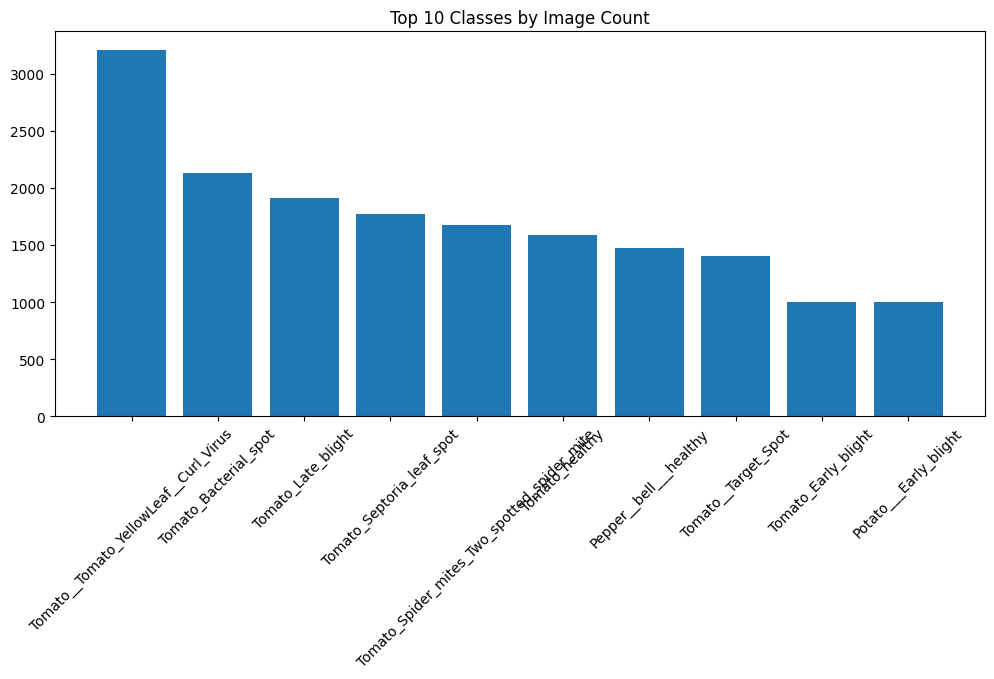

In [8]:
plt.figure(figsize=(12,5))
plt.bar(df["Class"][:10], df["Image Count"][:10])
plt.xticks(rotation=45)
plt.title("Top 10 Classes by Image Count")
plt.show()

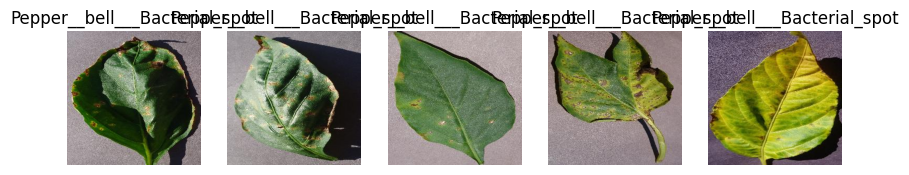

In [9]:
sample_class = classes[0]
sample_path = os.path.join(data_dir, sample_class)

images = os.listdir(sample_path)[:5]

plt.figure(figsize=(10,5))

for i, img_name in enumerate(images):
    img_path = os.path.join(sample_path, img_name)
    img = Image.open(img_path)

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(sample_class)

plt.show()

In [10]:
df.to_csv("dataset_summary.csv", index=False)

print("Dataset summary saved!")

Dataset summary saved!
